# Image Classification using Transfer Learning
## Deteksi Jenis Sampah di Sekitar Kampus

Nama: Sofyan Didik Asmara  
Mata Kuliah: Machine Learning  
Materi: Week 13 - Transfer Learning  



## 1. Pendahuluan

Transfer Learning adalah metode machine learning yang memanfaatkan model yang sudah dilatih sebelumnya pada dataset besar, kemudian digunakan kembali untuk menyelesaikan tugas baru.

Pada tugas ini, Transfer Learning digunakan untuk mendeteksi jenis sampah di sekitar kampus. Model pre-trained MobileNetV2 digunakan karena ringan dan cukup baik untuk klasifikasi gambar.


## 2. Import Library

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 3. Menentukan Lokasi Dataset

Pastikan dataset sudah di-download dari Kaggle dan di-extract. Letakkan folder dataset di folder yang sama dengan notebook.

Jika nama folder berbeda, ubah bagian DATA_DIR sesuai lokasi dataset kamu.


In [3]:
DATA_DIR = "TrashType_Image_Dataset"

if not os.path.exists(DATA_DIR):
    DATA_DIR = "TrashType_Image_Dataset/TrashType_Image_Dataset"

print("Dataset path:", DATA_DIR)
print("Folder ditemukan:", os.path.exists(DATA_DIR))

if os.path.exists(DATA_DIR):
    print("Isi folder:")
    print(os.listdir(DATA_DIR))


Dataset path: TrashType_Image_Dataset
Folder ditemukan: True
Isi folder:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 4. Parameter Dataset

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
VALIDATION_SPLIT = 0.2


## 5. Load Dataset

Dataset dibagi menjadi data training dan validation. Data training digunakan untuk melatih model, sedangkan data validation digunakan untuk menguji performa model.


In [5]:
train_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Nama kelas:", class_names)
print("Jumlah kelas:", num_classes)


Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Nama kelas: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Jumlah kelas: 6


## 6. Menampilkan Contoh Gambar

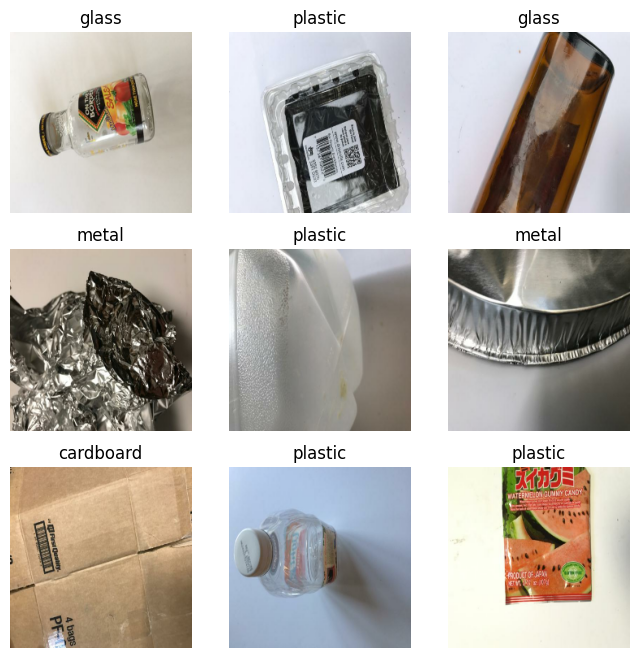

In [6]:
plt.figure(figsize=(8, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()


## 7. Optimasi Dataset

Prefetch digunakan agar proses training menjadi lebih cepat.


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


## 8. Data Augmentation

Data augmentation digunakan untuk menambah variasi gambar, sehingga model tidak mudah overfitting.


In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


## 9. Membuat Model Transfer Learning

Model MobileNetV2 digunakan sebagai feature extractor. Layer utama MobileNetV2 dibekukan, sehingga hanya classifier akhir yang dilatih.


In [9]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 10. Compile Model

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


## 11. Training Model

Epoch dibuat lebih sedikit agar waktu training tidak terlalu lama. EarlyStopping digunakan agar training berhenti otomatis jika validation loss tidak membaik.


In [11]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)


Epoch 1/10


c:\Program Files\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


64/64 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.5084 - loss: 1.2589 - val_accuracy: 0.7287 - val_loss: 0.7742
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.7161 - loss: 0.7535 - val_accuracy: 0.7545 - val_loss: 0.6485
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.7745 - loss: 0.6074 - val_accuracy: 0.7802 - val_loss: 0.6052
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.7868 - loss: 0.5921 - val_accuracy: 0.8099 - val_loss: 0.5603
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.8007 - loss: 0.5455 - val_accuracy: 0.8099 - val_loss: 0.5428
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.8140 - loss: 0.5123 - val_accuracy: 0.8139 - val_loss: 0.5191
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.8279 - loss: 0.4764 - val_accuracy: 0.8099 - val_loss: 0.5260
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.8284 - loss: 0.4604 - val_accuracy: 0.8119 - val_loss: 0.5269
Ep

## 12. Visualisasi Accuracy dan Loss

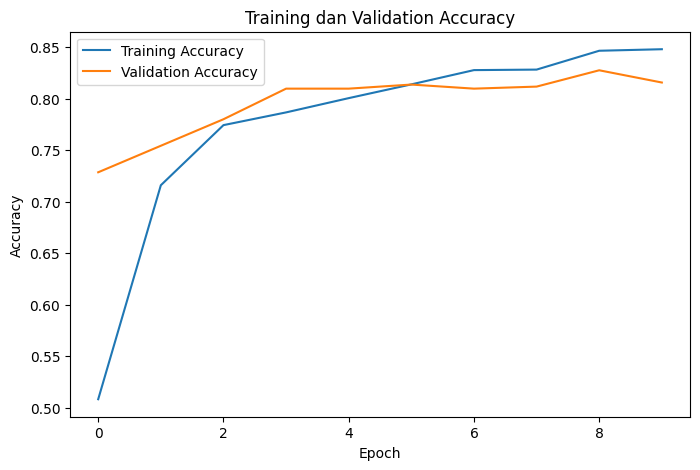

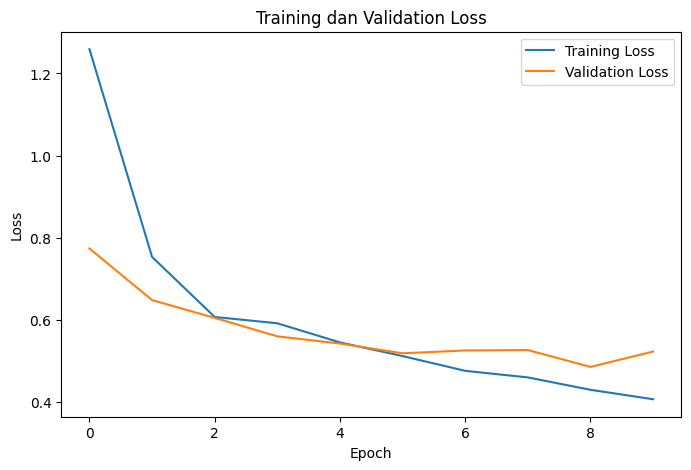

In [12]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Training dan Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("Training dan Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


## 13. Evaluasi Model

In [13]:
val_loss, val_accuracy = model.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)


16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8277 - loss: 0.4859
Validation Loss: 0.485947847366333
Validation Accuracy: 0.8277227878570557


## 14. Prediksi Contoh Gambar

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


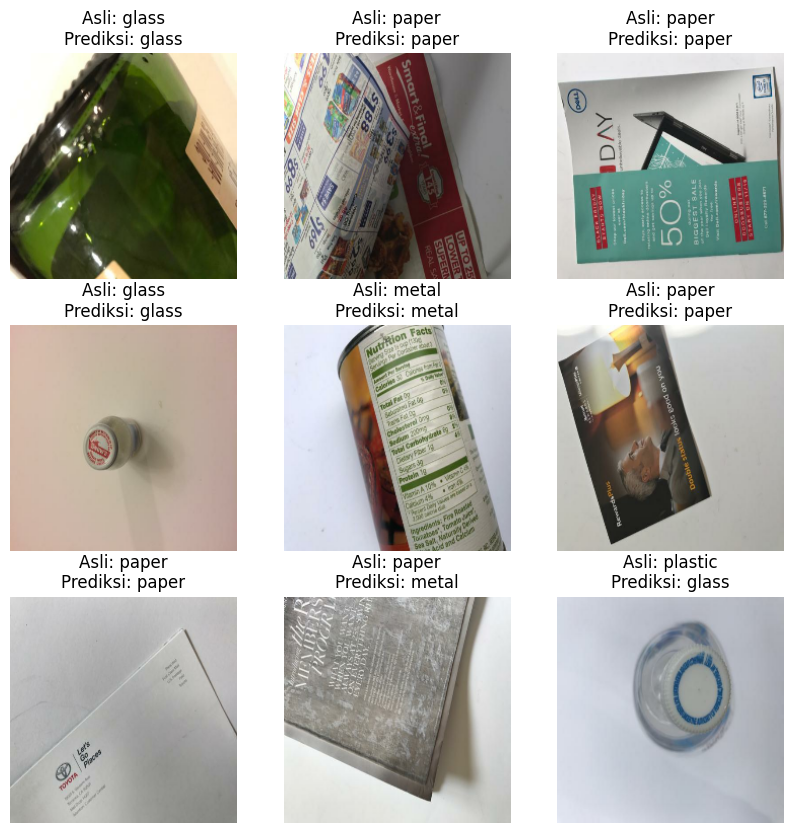

In [14]:
plt.figure(figsize=(10, 10))

for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i]]
        pred_label = class_names[predicted_labels[i]]

        plt.title(f"Asli: {true_label}\nPrediksi: {pred_label}")
        plt.axis("off")

plt.show()


## 15. Kesimpulan

Pada tugas ini telah dibuat model klasifikasi jenis sampah menggunakan metode Transfer Learning. Model yang digunakan adalah MobileNetV2 dengan bobot pre-trained dari ImageNet.

Transfer Learning membantu proses training menjadi lebih cepat karena model sudah memiliki pengetahuan awal dari dataset besar. Pada tugas ini, MobileNetV2 digunakan sebagai feature extractor, sedangkan bagian classifier akhir disesuaikan dengan jumlah kelas pada dataset sampah.

Hasil training dapat dilihat dari grafik accuracy dan loss. Jika validation accuracy semakin meningkat dan validation loss semakin menurun, maka model dapat dikatakan belajar dengan baik.

Model ini dapat digunakan sebagai dasar untuk sistem deteksi jenis sampah di sekitar kampus, sehingga dapat membantu proses pemilahan sampah secara otomatis.
